In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import numpy as np
import re
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Unfortunately did not explore or use glycan_binding.pkl as time constraint did not allow me to do as mush as I wanted
glycan_list = pd.read_csv('data/glycan_embedding/glycan_list.csv')
df_glycan = pd.read_pickle('data/glycan_embedding_fixed/df_glycan.pkl') 
n_glycans = pd.read_pickle('data/glycan_embedding_fixed/N_glycans_df.pkl')

# Prepare glycan sequences
concatenated_sequences = pd.concat([df_glycan['glycan'], glycan_list['glycan']])

print(f"Total unique glycan sequences: {len(concatenated_sequences)}")

Total unique glycan sequences: 50594


In [2]:
# Tokenizer that splits on brackets and parentheses
def glycan_tokenizer(sequence):
    tokens = re.findall(r'[A-Za-z]+\([a-z0-9\-]+\)|[A-Za-z]+\[|\][A-Za-z]+|[\w?]+', sequence)
    return [t for t in tokens if t]

# Create tfidf vectors
vectorizer = TfidfVectorizer(
    tokenizer=glycan_tokenizer,
    lowercase=False,
    max_features=500 # Could use more for better results but I am running this on my laptop
)

tfidf_matrix = vectorizer.fit_transform(concatenated_sequences)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

/home/student/miniconda3/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TF-IDF matrix shape: (50594, 500)


In [3]:
# Fit nearest neighbors model
nn_model = NearestNeighbors(n_neighbors=5, metric='cosine') # Chaning k hyper parameter could lead to better results
nn_model.fit(tfidf_matrix)

# Function for finding similar glycans
def find_similar_glycans(query_sequence, top_n=5):
    query_vec = vectorizer.transform([query_sequence])
    distances, indices = nn_model.kneighbors(query_vec, n_neighbors=top_n+1)
    
    # Remove the glycan finding itself
    similar_sequences = concatenated_sequences.iloc[indices[0][1:]]
    similar_distances = distances[0][1:]
    
    return pd.DataFrame({
        'glycan': similar_sequences.values,
        'similarity_score': 1 - similar_distances
    })

# Example of similarity from model using glycan form glycan_list
example_glycan = glycan_list['glycan'].iloc[0]
similar_glycans = find_similar_glycans(example_glycan)
print(f"Glycans similar to {example_glycan}:")
print(similar_glycans)

Glycans similar to Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc:
                                              glycan  similarity_score
0  {Fuc(a1-?)}Gal(b1-4)GlcNAc(b1-2)Man(a1-3)[GlcN...          0.972430
1  {Fuc(a1-?)}Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcN...          0.972430
2  Fuc(a1-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-3)[GlcNAc...          0.972430
3  Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[Man(a1-3)]Man(b...          0.963709
4  {Fuc(a1-?)}Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcN...          0.956356


In [4]:
# Get attributes for similar glycans
def get_attributes(glycan_df):
    context = pd.merge(
        glycan_df,
        df_glycan[['glycan', 'Species', 'tissue_sample']],
        on='glycan',
        how='left'
    )

    return context
print(glycan_list.iloc[0:1][['glycan', 'tissue_species', 'tissue_sample']])
#example_glycan_attributes = get_attributes(glycan_list.iloc[0])
similar_glycans_attributes = get_attributes(similar_glycans)
print("\nBiological context of similar glycans:")
print(similar_glycans_attributes)

                                              glycan    tissue_species  \
0  Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...  ['Homo_sapiens']   

  tissue_sample  
0     ['blood']  

Biological context of similar glycans:
                                              glycan  similarity_score  \
0  {Fuc(a1-?)}Gal(b1-4)GlcNAc(b1-2)Man(a1-3)[GlcN...          0.972430   
1  {Fuc(a1-?)}Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcN...          0.972430   
2  Fuc(a1-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-3)[GlcNAc...          0.972430   
3  Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[Man(a1-3)]Man(b...          0.963709   
4  {Fuc(a1-?)}Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcN...          0.956356   

          Species                  tissue_sample  
0  [Mus_musculus]                        [brain]  
1  [Mus_musculus]                        [brain]  
2  [Homo_sapiens]                             []  
3  [Homo_sapiens]  [secretion_of_lacrimal_gland]  
4  [Mus_musculus]                        [brain]  


In [5]:
# Get tfidf vectors for n_glycans
n_glycan_vecs = vectorizer.transform(n_glycans['glycan'].dropna())

# Calculate similarity among n_glycans
from sklearn.metrics.pairwise import cosine_similarity
n_similarity = cosine_similarity(n_glycan_vecs)
avg_n_similarity = np.mean(n_similarity[np.triu_indices_from(n_similarity, k=1)])

# Compare to random glycans
random_sample = concatenated_sequences.sample(n_glycan_vecs.shape[0])
random_vecs = vectorizer.transform(random_sample)
random_similarity = cosine_similarity(random_vecs)
avg_random_similarity = np.mean(random_similarity[np.triu_indices_from(random_similarity, k=1)])

print(f"\nValidation Results:")
print(f"Average similarity among N-glycans: {avg_n_similarity:.3f}")
print(f"Average similarity among random glycans: {avg_random_similarity:.3f}")


Validation Results:
Average similarity among N-glycans: 0.629
Average similarity among random glycans: 0.113


Higher similarity amon N-glycans, and lower with random samples shows that the model how we want it to.
Now let's visualize this

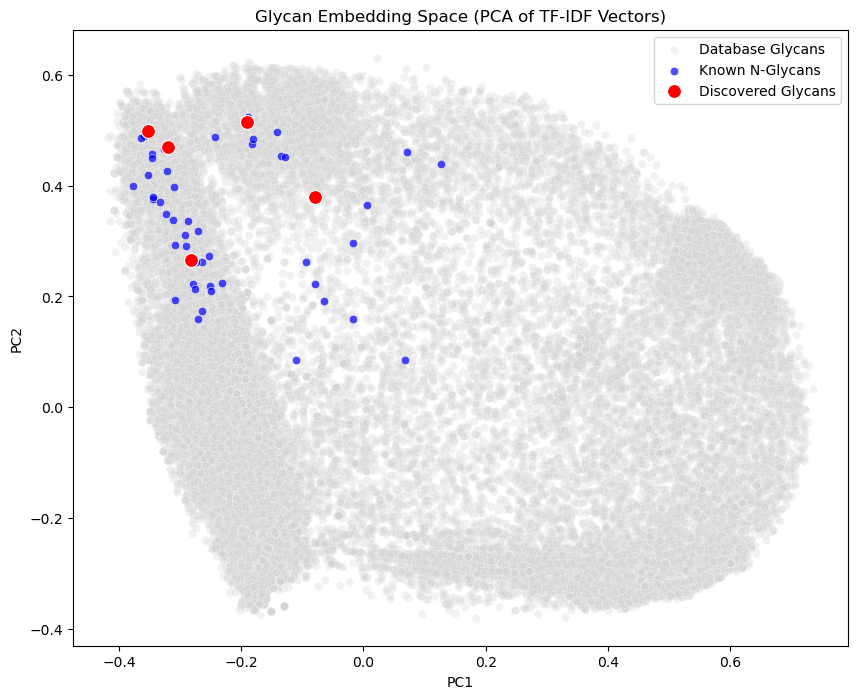

In [6]:
# Reduce dimensions with PCA (faster than t-SNE for our purposes)
pca = PCA(n_components=2)
all_sequences_to_plot = pd.concat([
    df_glycan['glycan'],
    n_glycans['glycan'],
    glycan_list['glycan']
]).drop_duplicates().dropna()
all_vectors = vectorizer.transform(all_sequences_to_plot)
tfidf_2d = pca.fit_transform(all_vectors.toarray())

# Create a DataFrame for visualization
viz_df = pd.DataFrame(tfidf_2d, columns=['PC1', 'PC2'])
viz_df['sequence'] = all_sequences_to_plot.values
viz_df['is_discovered'] = viz_df['sequence'].isin(glycan_list['glycan'])
viz_df['is_nglycan'] = viz_df['sequence'].isin(n_glycans['glycan'])
viz_df['is_database'] = ~viz_df['is_discovered'] & ~viz_df['is_nglycan']

plt.figure(figsize=(10, 8))

# database glycans in gray
sns.scatterplot(
    data=viz_df[viz_df['is_database']],
    x='PC1', y='PC2',
    color='lightgray',
    alpha=0.3,
    label='Database Glycans'
)

# n_glycans in blue
sns.scatterplot(
    data=viz_df[viz_df['is_nglycan']],
    x='PC1', y='PC2',
    color='blue',
    alpha=0.7,
    label='Known N-Glycans'
)

# Discovered glycans in red
sns.scatterplot(
    data=viz_df[viz_df['is_discovered']],
    x='PC1', y='PC2',
    color='red',
    alpha=1,
    s=100,
    label='Discovered Glycans'
)

plt.title("Glycan Embedding Space (PCA of TF-IDF Vectors)")
plt.legend()
plt.show()

Unfortunately I did not have the time to do more. I wish I could. I would look into the glycan_binding.pkl dataframe, and try other more complex approaches like using word2vec or a transformer. If glycan_binding.pkl provided links between glycans we could even use GNN.